In [1]:
import uproot
import awkward as ak
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/xzcapcdo/lundtoptagger/")
from plotting.utils_plots_matplotlib import hist_with_errors
from tools.GNN_model_weight.utils_newdata import JSD

In [3]:
score_files_paths = [
    "/home/xzcapcdo/lundtoptagger/data/part_0_0.25/part0_0.25percent/*.root"
]



tree_name = "FlatSubstructureJetTree"

In [4]:
# dsid_weight_map = {    
#     364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
#     364703: 26452000.0   * 0.011653  / 24.124114769654568,
#     364704: 254610.0 * 0.013358 / 0.6689032716609136,
#     364705: 4553.5   * 0.014513 / 0.021711071504255608, 
#     364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
#     364707: 16.214 * 0.011092 / 7.647190915207464e-05,
#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803
# }
# for key, val in dsid_weight_map.items():
#     print(f"key: {key}, val: {val}")

dsid_weight_map = {
    364703: 12823.94988,
    364704: 5081.45927,
    364705: 3017.75098,
    364706: 4371.00012,
    364707: 2349.98631,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803,
    801661: 1.0,

    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
}

In [5]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]
data = uproot.concatenate(score_files_paths_with_trees)

In [6]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(data.fields)

['fjet_m',
 'fjet_pt',
 'fjet_eta',
 'fjet_phi',
 'fjet_truth_label',
 'fjet_Nconst_Charged',
 'GN3X_phtautauhad',
 'GN3X_phbb',
 'GN3X_phcc',
 'GN3X_ptop',
 'GN3X_pqcdbb',
 'GN3X_pqcdbx',
 'GN3X_pqcdcx',
 'GN3X_pqcdll',
 'GN3X_pWqq',
 'labels',
 'EventInfo_mcEventWeight',
 'EventInfo_mcChannelNumber',
 'fjet_weight_pt_top',
 'fjet_LundNet_plus_GN3X_score',
 'fjet_LundNet_score']

In [7]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 115161
Background jets: 792951
Total: 908112


In [8]:
# weights = data["fjet_weight_pt"]
# weights = np.ones_like(data["fjet_weight_pt"])
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

In [9]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [10]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN3X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN3X_pqcd"],
        data["GN3X_phbb"],
        data["GN3X_phcc"],
        data["GN3X_ptop"],
        step=0.01
    )
    print(f"GN3X best AUC: {GN3X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN3X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [11]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05

try:
    if "GN3X_pqcd" in data.fields:
        pqcd = data["GN3X_pqcd"]
    else:
        # Calculate pqcd as sum of components if not present
        pqcd = data["GN3X_pqcdbb"] + data["GN3X_pqcdbx"] + data["GN3X_pqcdcx"] + data["GN3X_pqcdll"]

    denoms = fhbb * data["GN3X_phbb"] + fhcc * data["GN3X_phcc"] + (1 - fhbb - fhcc) * pqcd
    gn3x_scores = np.log(data["GN3X_ptop"] / denoms)
except Exception as e:
    print(f"Error calculating GN3X scores: {e}")
    gn3x_scores = None

In [12]:
models = {
    "LundNet": {
        "scores": data["fjet_LundNet_score"]
    },
    "LundNet+GN3X": {
        "scores": data["fjet_LundNet_plus_GN3X_score"]
    },
    "GN3X": {
        "scores": gn3x_scores
    }
}

# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

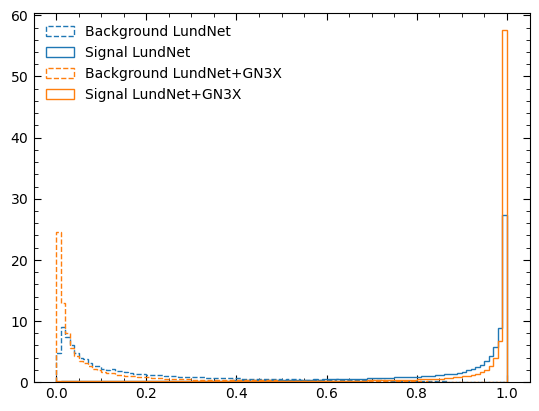

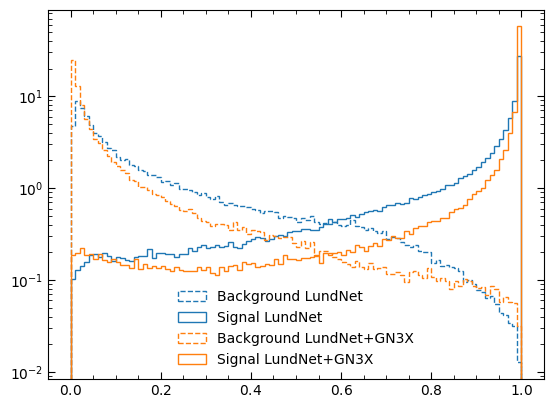

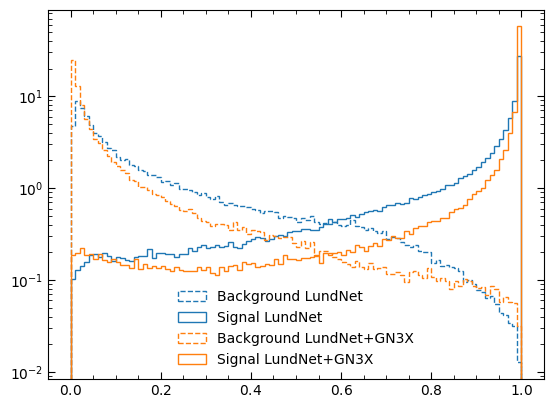

In [13]:
# Extract scores and labels
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

selected_models = ["LundNet", "LundNet+GN3X"]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

#selected_models = ["GN3X"]
#for i, model in enumerate(selected_models):
#    scores = models[model]["scores"]
#    hist_params["color"] = f"C{i}"
#    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

In [14]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    if scores is None:
        print(f"Skipping {model} because scores are None")
        continue

    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet: 0.9488391280174255
50% signal efficiency threshold for LundNet+GN3X: 0.995219886302948
50% signal efficiency threshold for GN3X: 1.258935753836065


In [15]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

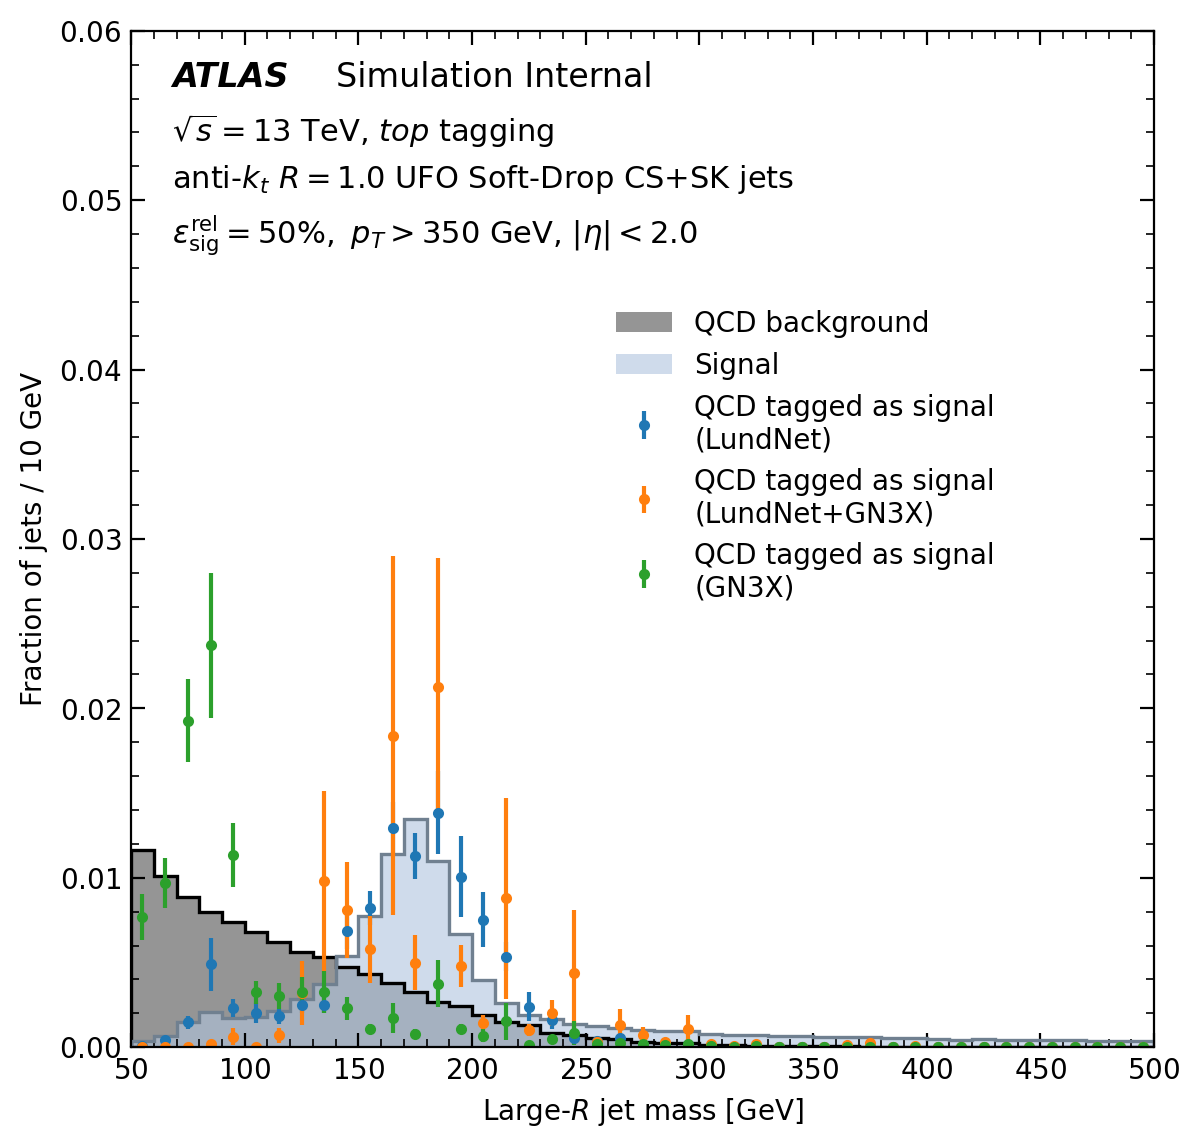

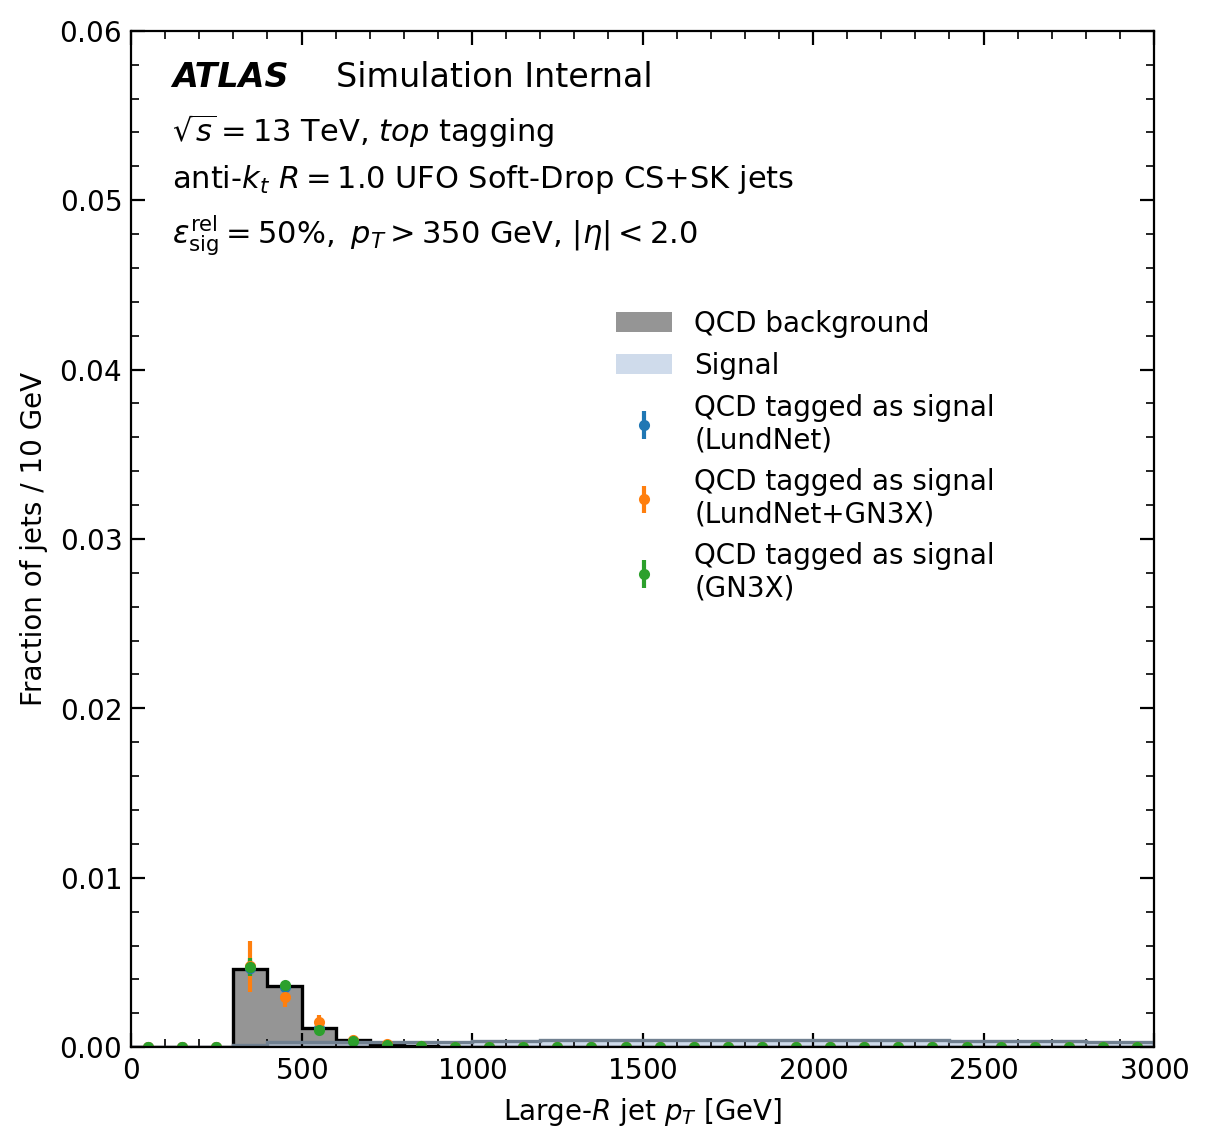

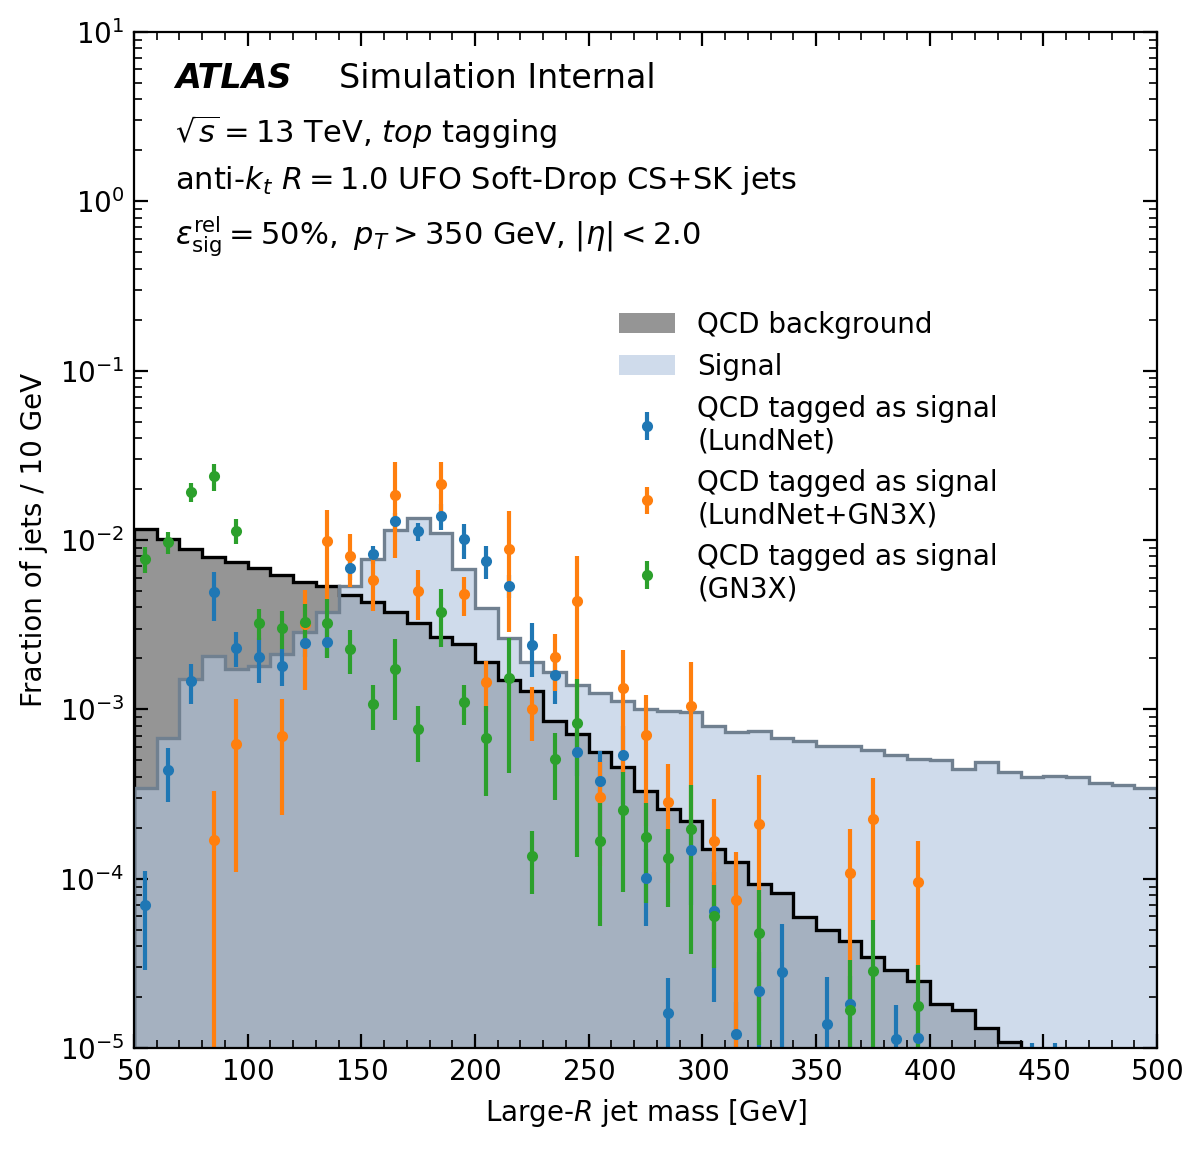

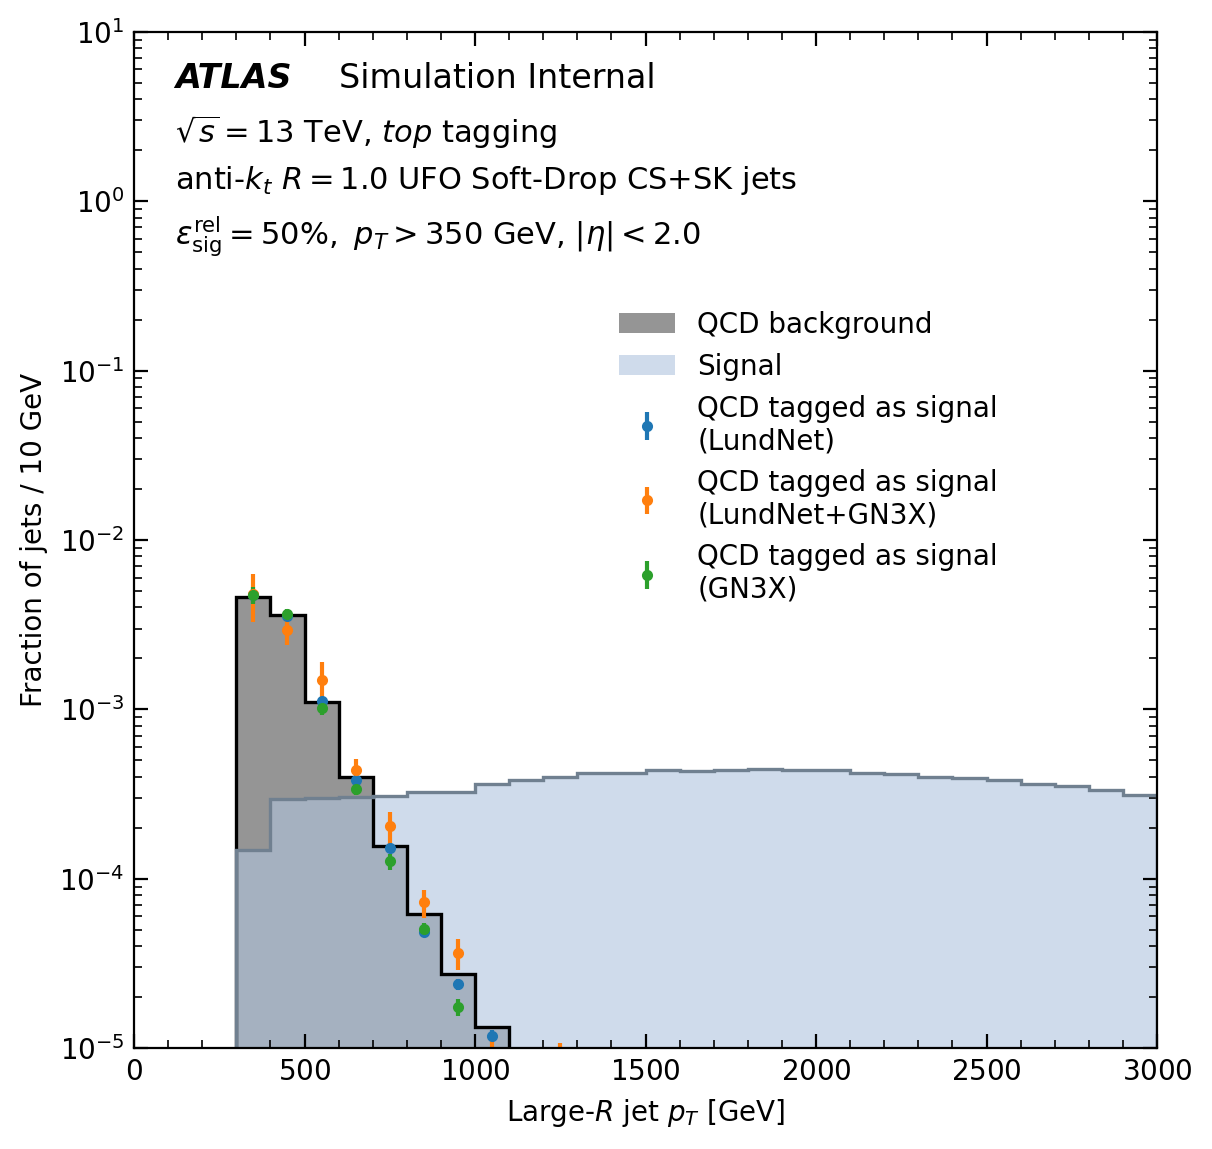

In [16]:
selected_models = models.keys()  # Use all models for now
selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
plot_signal_after_tagging = False
plot_errorbars = True
calc_jsd = False

plot_params = {
    "lin": {
        "yscale": "linear",
        "ylim": (0, 0.06),
    },
    "log": {
        "yscale": "log",
        "ylim": (1e-5, 10),
    }
}

for params in plot_params.values():
    for var in var_params:
        fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=200)

        var_data = data[var]
        hist_params = dict(
            bins = var_params[var]["bins"],
            range = var_params[var]["range"],
            density = True,
        )

        # QCD background: shaded dark gray with black outline
        bkg_counts = plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], label="QCD background", color="dimgray", alpha=0.7, **hist_params)[0]
        plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], histtype="step", color="black", linewidth=1.2, **hist_params)
        # Signal: fill with neutral, light colour
        plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], label="Signal", color="lightsteelblue", alpha=0.6, **hist_params)
        plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], histtype="step", color="slategray", linewidth=1.2, **hist_params)

        for i, model in enumerate(selected_models):
            tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

            if i !=0 and calc_jsd:
                bkg_counts_tagged = np.histogram(
                    ak.to_numpy(var_data[(labels==0) & tagged_as_signal & selection]),
                    weights=ak.to_numpy(weights[(labels==0) & tagged_as_signal & selection]),
                    **hist_params
                )[0]
                JSD_value = JSD(bkg_counts, bkg_counts_tagged)*100  # TODO: maybe shouldn't be expressed as a percentage
                JSD_label = f", JSD = {JSD_value:.2f}%"
            else:
                JSD_label = ""

            if plot_errorbars:
                extra_args = dict(fmt='.')
                hist_plot_func = hist_with_errors
            else:
                extra_args = dict(histtype="step", linestyle='-' if i==0 else '--', linewidth=1.5)
                hist_plot_func = plt.hist
            hist_plot_func(
                var_data[(labels==0) & tagged_as_signal & selection],
                weights=weights[(labels==0) & tagged_as_signal & selection],
                label=f"QCD tagged as signal{JSD_label}\n({model})",
                **hist_params, **extra_args
            )
            if plot_signal_after_tagging:
                hist_plot_func(
                    var_data[(labels==1) & tagged_as_signal & selection],
                    weights=weights[(labels==1) & tagged_as_signal & selection],
                    label=f"Signal tagged as signal{JSD_label}\n({model})",
                    **hist_params, **extra_args
                )

        # Add ATLAS label
        atlas_label = r"ATLAS"
        atlas_sim = r"Simulation Internal"
        atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
        jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
        selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
        text_args = {"transform": ax.transAxes, "va": 'top'}
        ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
        ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
        ax.text(0.04, 0.92, atlas_info,     fontsize=11, **text_args)
        ax.text(0.04, 0.87, jet_info,       fontsize=11, **text_args)
        ax.text(0.04, 0.82, selection_info, fontsize=11, **text_args)

        plt.xlim(var_params[var]["range"])
        plt.xlabel(var_params[var]["title"])
        plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
        plt.yscale(params["yscale"])
        plt.ylim(params["ylim"])
        # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
        plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
        plt.show()

In [17]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]

mass_cuts = [
    (40, float('inf')),
    (150, 200)
]
pt_min = 350
eta_max = 2
# eta_max = float('inf')


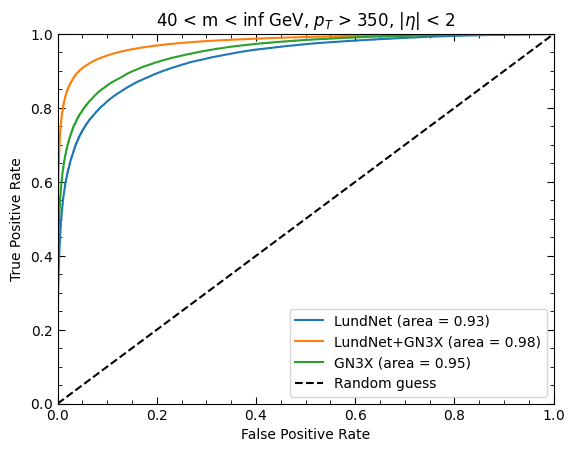

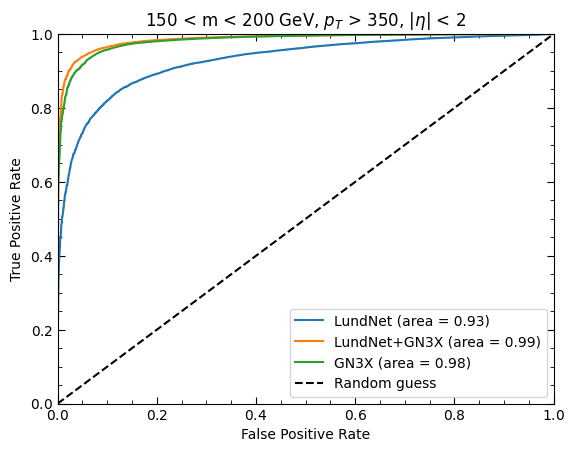

In [18]:
for mass_cut in mass_cuts:
    m_min, m_max = mass_cut
    cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (np.abs(eta) < eta_max)
    y_truth_cuts = data["labels"][cuts]
    weights_cuts = weights[cuts]

    for trained_model in models:
        y_pred = models[trained_model]["scores"] if cuts is None else models[trained_model]["scores"][cuts]
        fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
        roc_auc = auc(fpr, tpr)

        models[trained_model][f"fpr_{m_min}-{m_max}"] = fpr
        models[trained_model][f"tpr_{m_min}-{m_max}"] = tpr

        plt.plot(fpr, tpr, label=f"{trained_model} (area = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

    plt.title(f"{m_min} < m < {m_max} GeV, $p_T$ > {pt_min}, |$\eta$| < {eta_max}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.legend(loc="lower right")
    # plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left")
    plt.show()

/tmp/ipykernel_193332/2914423515.py:19: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{trained_model}")
/tmp/ipykernel_193332/2914423515.py:57: RuntimeWarning: divide by zero encountered in divide
  interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
/tmp/ipykernel_193332/2914423515.py:58: RuntimeWarning: divide by zero encountered in divide
  ref_rej = 1/ref_fpr
/tmp/ipykernel_193332/2914423515.py:59: RuntimeWarning: invalid value encountered in divide
  ratio = interp_rej / ref_rej


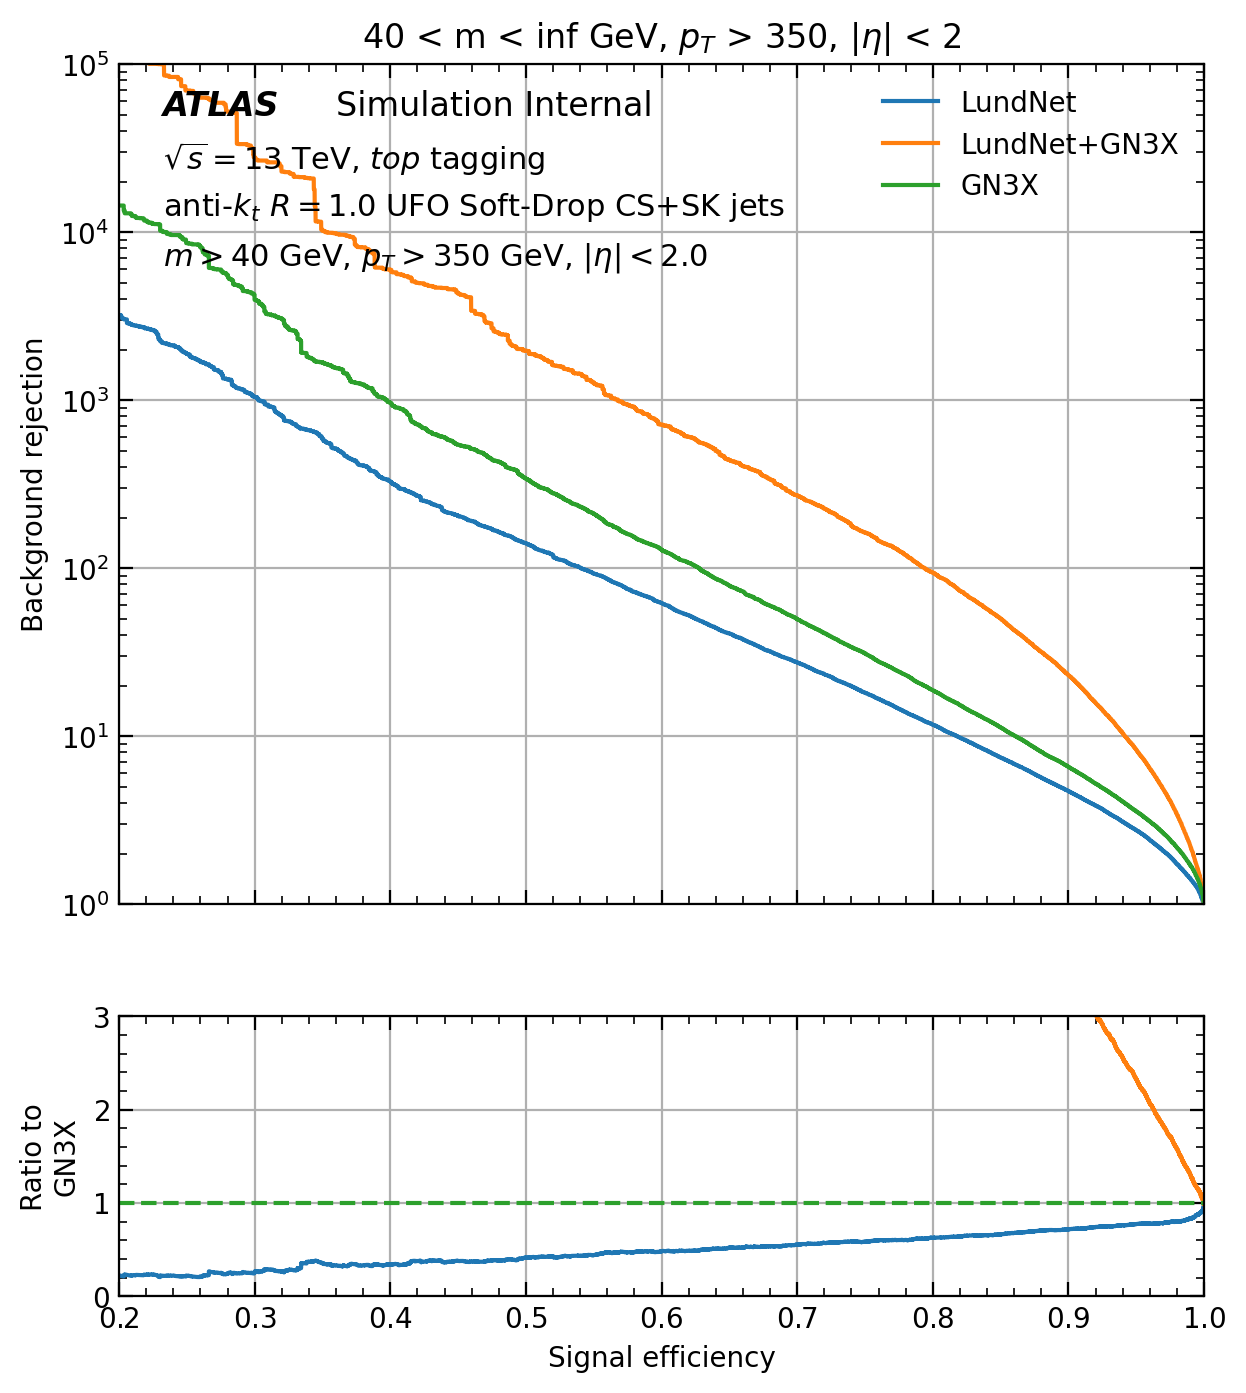

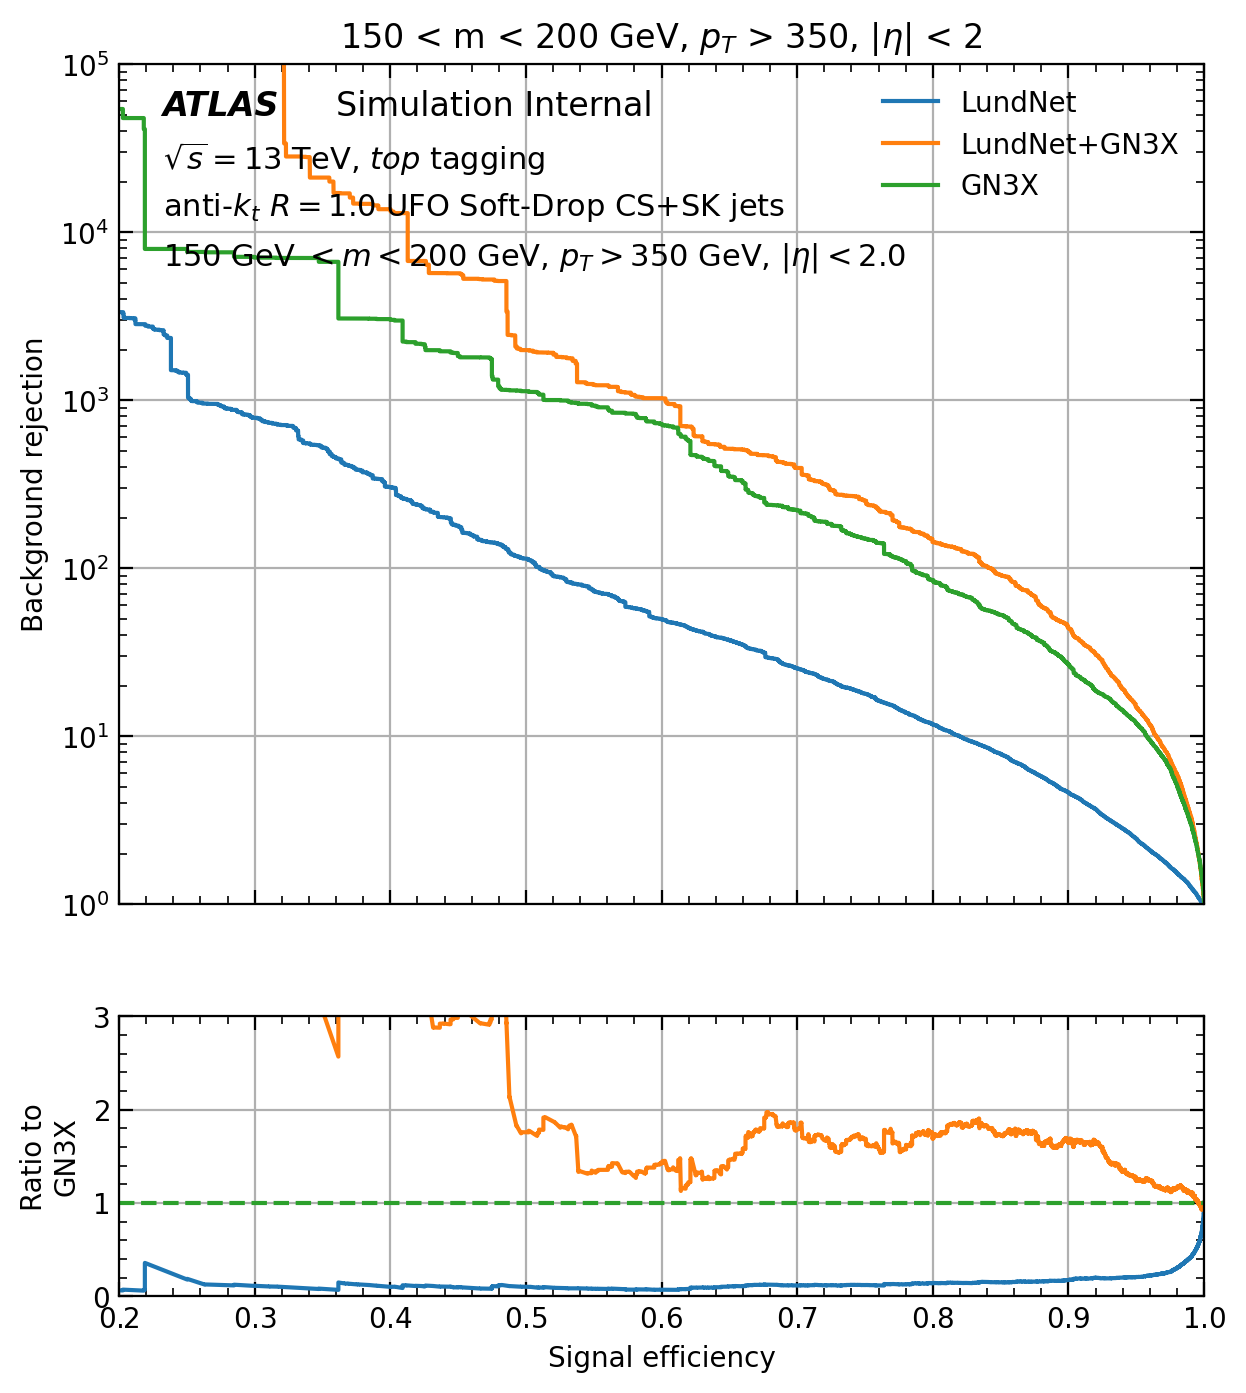

In [19]:
selected_models = models.keys()  # Use all models for now

show_grid = True

plot_ratio = True
reference_model = "GN3X"

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for trained_model in selected_models:
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        ax1.plot(tpr, 1/fpr, label=f"{trained_model}")

    ax1.set_title(f"{m_min} < m < {m_max} GeV, $p_T$ > {pt_min}, |$\eta$| < {eta_max}")
    plt.xlabel("Signal efficiency")
    ax1.set_ylabel("Background rejection")
    plt.xlim([0.2, 1])
    ax1.set_ylim([1, 1e5])
    ax1.set_yscale("log")
    ax1.legend(frameon=False)
    # ax1.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")

    # Add ATLAS label
    atlas_label = r"ATLAS"
    atlas_sim = r"Simulation Internal"
    atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
    jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
    mass_selection_info = f"$m > {m_min}$ GeV, " if m_max==float('inf') else f"${m_min}$ GeV $ < m < {m_max}$ GeV, "
    selection_info = mass_selection_info + f"$p_T > {pt_min}$ GeV, $|\\eta| < {eta_max:.1f}$"
    text_args = {"transform": ax1.transAxes, "va": 'top'}
    ax1.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
    ax1.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
    ax1.text(0.04, 0.91, atlas_info,     fontsize=11, **text_args)
    ax1.text(0.04, 0.85, jet_info,       fontsize=11, **text_args)
    ax1.text(0.04, 0.79, selection_info, fontsize=11, **text_args)

    # Ratio subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]

        for i, trained_model in enumerate(selected_models):
            color = f"C{i}"
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            # Interpolate to reference tpr points
            interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
            ref_rej = 1/ref_fpr
            ratio = interp_rej / ref_rej
            ax2.plot(ref_tpr, ratio, label=f"{trained_model} / {reference_model}", color=color)

        ax2.set_ylabel(f"Ratio to\n{reference_model}")
        ax2.set_ylim([0, 3])
        ax2.grid(show_grid)

    ax1.grid(show_grid)
    plt.show()